Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Training observations: 24000
Testing observations: 6000

Optimized XGBoost model successfully trained.
SHAP values successfully calculated.

Global SHAP Feature Importance


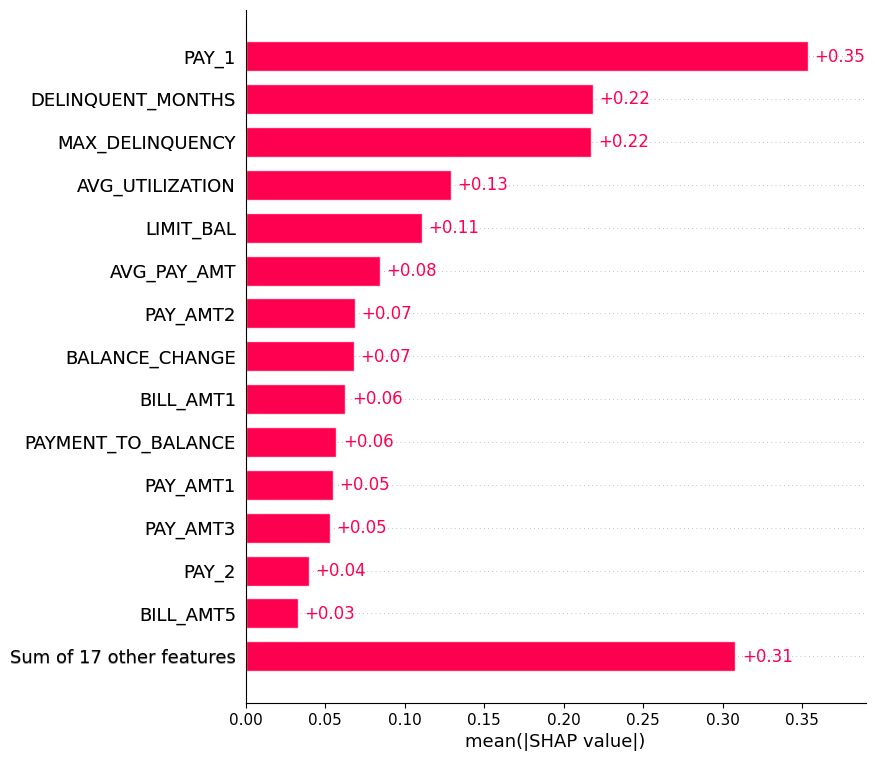


SHAP Feature Impact


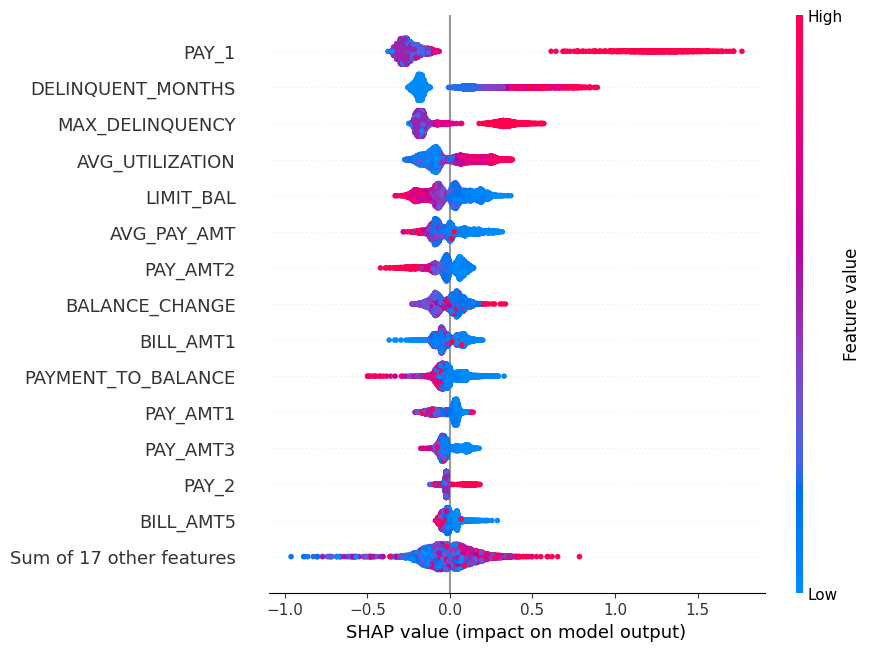


Highest-Risk Customer
---------------------------
Predicted Default Probability: 88.07%
Actual Default: 1


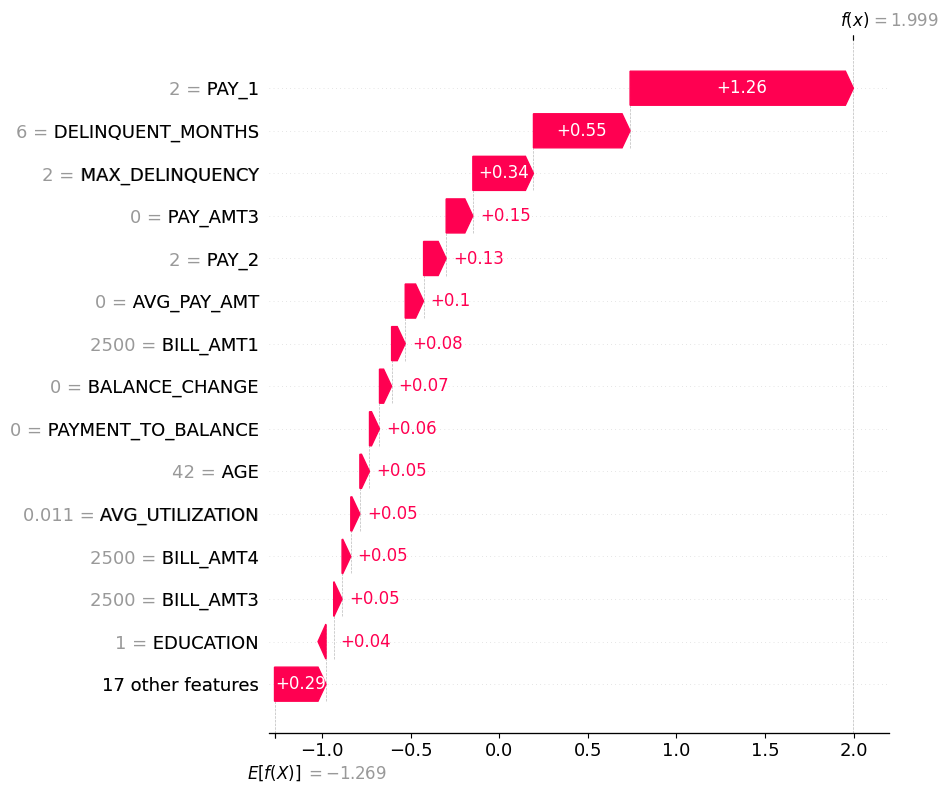

In [0]:
# ============================================================
# CREDIT CARD DEFAULT PREDICTION — MODEL INTERPRETATION
# ============================================================

%pip install xgboost shap


# ------------------------------------------------------------
# 1. LOAD AND PREPARE DATA
# ------------------------------------------------------------

import pandas as pd
import numpy as np

df = spark.table("CCC_FEATURES")
pdf = df.toPandas()

# Create indicator for customers without a positive average balance
pdf["NO_POSITIVE_BALANCE"] = (
    pdf["AVG_BILL_AMT"] <= 0
).astype(int)

# Replace undefined payment-to-balance ratios with 0
pdf["PAYMENT_TO_BALANCE"] = (
    pdf["PAYMENT_TO_BALANCE"].fillna(0)
)


# ------------------------------------------------------------
# 2. DEFINE TARGET AND PREDICTORS
# ------------------------------------------------------------

features = [
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",

    "PAY_1",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",

    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",

    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",

    "AVG_BILL_AMT",
    "AVG_PAY_AMT",
    "AVG_UTILIZATION",
    "PAYMENT_TO_BALANCE",
    "NO_POSITIVE_BALANCE",
    "DELINQUENT_MONTHS",
    "MAX_DELINQUENCY",
    "BALANCE_CHANGE"
]

X = pdf[features]
y = pdf["dpnm"]


# ------------------------------------------------------------
# 3. RECREATE TRAIN/TEST SPLIT
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))


# ------------------------------------------------------------
# 4. TRAIN OPTIMIZED XGBOOST MODEL
# ------------------------------------------------------------

from xgboost import XGBClassifier

best_xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,

    # Optimized hyperparameters from RandomizedSearchCV
    subsample=0.8,
    n_estimators=100,
    min_child_weight=1,
    max_depth=5,
    learning_rate=0.05,
    gamma=0.1,
    colsample_bytree=0.7
)

best_xgb.fit(X_train, y_train)

print("\nOptimized XGBoost model successfully trained.")


# ------------------------------------------------------------
# 5. CALCULATE SHAP VALUES
# ------------------------------------------------------------

import shap

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer(X_test)

print("SHAP values successfully calculated.")


# ------------------------------------------------------------
# 6. GLOBAL FEATURE IMPORTANCE
# ------------------------------------------------------------

print("\nGlobal SHAP Feature Importance")

shap.plots.bar(
    shap_values,
    max_display=15
)


# ------------------------------------------------------------
# 7. FEATURE IMPACT AND DIRECTION
# ------------------------------------------------------------

print("\nSHAP Feature Impact")

shap.plots.beeswarm(
    shap_values,
    max_display=15
)


# ------------------------------------------------------------
# 8. IDENTIFY HIGHEST-RISK CUSTOMER
# ------------------------------------------------------------

predicted_risk = best_xgb.predict_proba(X_test)[:, 1]

highest_risk_position = np.argmax(predicted_risk)

print("\nHighest-Risk Customer")
print("---------------------------")
print(
    "Predicted Default Probability:",
    f"{predicted_risk[highest_risk_position]:.2%}"
)

print(
    "Actual Default:",
    y_test.iloc[highest_risk_position]
)


# ------------------------------------------------------------
# 9. EXPLAIN HIGHEST-RISK CUSTOMER
# ------------------------------------------------------------

shap.plots.waterfall(
    shap_values[highest_risk_position],
    max_display=15
)


### Global Feature Importance

#SHAP analysis indicates that recent repayment behavior and delinquency are
#among the strongest drivers of the optimized XGBoost model.

#`PAY_1`, representing the most recent repayment status, had the largest
#individual mean absolute SHAP value. Engineered behavioral features also
#contributed substantially to model predictions. `DELINQUENT_MONTHS` and
#`MAX_DELINQUENCY` were the second- and third-most influential individual
#features, followed by `AVG_UTILIZATION`.

#Several engineered variables—including delinquency frequency, delinquency
#severity, average utilization, average payment amount, and balance change—
#ranked among the model's most influential features. This suggests that
#aggregating customers' historical payment and balance behavior provides
#useful predictive information beyond individual monthly observations.

#Mean absolute SHAP values measure the magnitude of a feature's influence,
#not whether higher values increase or decrease default risk. Directional
#effects are examined using the SHAP beeswarm analysis below.

### Individual Customer Explanation

#The highest-risk customer in the test set received a predicted default
#probability of **88.07%** and ultimately defaulted.

#The SHAP waterfall plot provides a local explanation of this prediction,
#showing how individual customer characteristics shifted the prediction away
#from the model's baseline risk and toward the final high-risk estimate.

#This example demonstrates how the model can provide both a risk score and an
#interpretable explanation of the factors contributing to an individual
#customer's predicted risk.